In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import boxcox, shapiro

from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [284]:
import warnings
warnings.filterwarnings("ignore")

In [285]:
df = pd.read_csv("database/casks_database__casks_valuation_2.csv")

## Data cleaning based on previous data analysis

In [ ]:
# Selecting data analysis selected features

df = df[['age', 'strength', 'distillery', 'region', 'cask_type', 'cask_filling',
         'previous_spirit', 'inf_adj_hammer_price_per_litre_of_alcohol']]

In [287]:
categorical_columns = ['distillery', 'region', 'cask_type', 'cask_filling', 'previous_spirit']
df[categorical_columns] = df[categorical_columns].fillna('Undisclosed')

In [288]:
df.isnull().sum()

age                                          94
strength                                      6
distillery                                    0
region                                        0
cask_type                                     0
cask_filling                                  0
previous_spirit                               0
inf_adj_hammer_price_per_litre_of_alcohol    10
dtype: int64

In [289]:
len(df)

562

In [290]:
df = df[df['strength'] >= 40]  # Remove casks with strength less than 40% ABV

In [291]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.isnull().sum()

age                                          0
strength                                     0
distillery                                   0
region                                       0
cask_type                                    0
cask_filling                                 0
previous_spirit                              0
inf_adj_hammer_price_per_litre_of_alcohol    0
dtype: int64

In [292]:
len(df)

459

In [293]:
df['distillery'] = df['distillery'].str.lower()
df['region'] = df['region'].str.lower()
df['cask_type'] = df['cask_type'].str.lower()
df['cask_filling'] = df['cask_filling'].str.lower()
df['previous_spirit'] = df['previous_spirit'].str.lower()

## X variables categorization based on previous data analysis

In [294]:
df = pd.get_dummies(df, columns=categorical_columns, drop_first=False, dtype=int)

In [295]:
df.columns = [col.replace(' ', '_') for col in df.columns]

In [296]:
df = df[['age', 'strength', 'distillery_macallan', 'distillery_springbank', 'region_campbeltown', 'cask_type_hogshead',
         'cask_type_butt', 'cask_filling_second_fill', 'inf_adj_hammer_price_per_litre_of_alcohol']]

## Y variable box-cox normalization based on previous data analysis

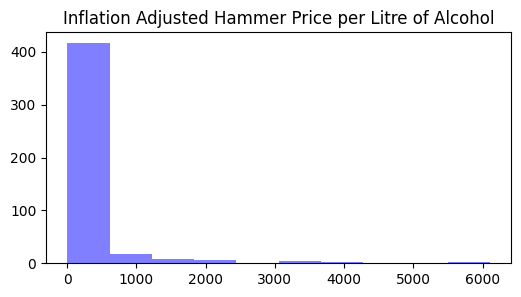

In [297]:
plt.figure(figsize=(6, 3))
plt.hist(df['inf_adj_hammer_price_per_litre_of_alcohol'], color='blue', alpha=0.5)
plt.title('Inflation Adjusted Hammer Price per Litre of Alcohol')
plt.show()

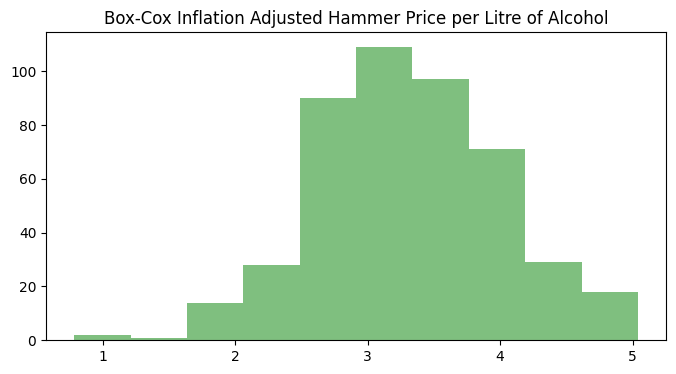

In [298]:
# Supondo que seus dados estejam em y
y_boxcox, fitted_lambda = boxcox(df['inf_adj_hammer_price_per_litre_of_alcohol'])

plt.figure(figsize=(8, 4))
plt.hist(y_boxcox, color='green', alpha=0.5)
plt.title('Box-Cox Inflation Adjusted Hammer Price per Litre of Alcohol')
plt.show()

df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'] = y_boxcox

In [299]:
Q1 = df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'].quantile(0.25)
Q3 = df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'].quantile(0.75)
IQR = Q3 - Q1

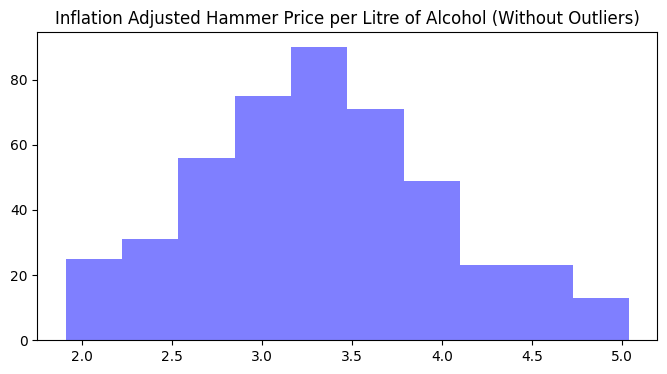

In [ ]:
filtro = (df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'] >= (Q1 - 1.5 * IQR)) & (df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'] <= (Q3 + 1.5 * IQR))
df = df[filtro].reset_index(drop=True)
plt.figure(figsize=(8, 4))
plt.hist(df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'], color='blue', alpha=0.5)
plt.title('Box-Cox Transformed Inflation Adjusted Hammer Price per Litre of Alcohol (Without Outliers)')
plt.show()

In [301]:
stat, p_value = shapiro(df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'])
print(f"P-value - Shapiro-Wilk: {p_value:.4f}")

P-value - Shapiro-Wilk: 0.0060


In [302]:
df = df.drop(columns=['inf_adj_hammer_price_per_litre_of_alcohol'])

## Split train and test data

In [303]:
x = df.drop(columns=['inf_adj_hammer_price_per_litre_of_alcohol_boxcox'])
y = df['inf_adj_hammer_price_per_litre_of_alcohol_boxcox']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [304]:
scaler_x_standard = StandardScaler()

x_train_scaled = x_train.copy()
x_train_scaled[['age', 'strength']] = scaler_x_standard.fit_transform(x_train_scaled[['age', 'strength']])

x_test_scaled = x_test.copy()
x_test_scaled[['age', 'strength']] = scaler_x_standard.transform(x_test_scaled[['age', 'strength']])

## Modeling

In [305]:
models_metrics = []
trained_models = {}

In [306]:
def linear_regression_best_model(x_train_scaled, x_test_scaled, y_train):

    model = LinearRegression()
    model.fit(x_train_scaled, y_train)

    y_pred = model.predict(x_test_scaled)

    return y_pred, model

In [307]:
def random_forest_best_model(x_train, x_test, y_train):

    model = RandomForestRegressor(random_state=1)

    param_grid = {
        'n_estimators': [25, 50, 100, 200, 250],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt', 'log2']
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(x_test)

    return y_pred, best_model

In [308]:
def svr_best_model(x_train_scaled, x_test_scaled, y_train):

    model = SVR(kernel='linear')

    param_grid = {
        'C': [0.1, 0.5, 1, 5, 10],
        'epsilon': [0.1, 0.2, 0.5],
        'kernel': ['linear', 'rbf', 'poly']
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(x_train_scaled, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(x_test_scaled)

    return y_pred, best_model

In [309]:
def gradient_boost_best_model(x_train, x_test, y_train):

    model = GradientBoostingRegressor(random_state=1)

    param_grid = {
        'n_estimators': [25, 50, 100, 200, 250],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(x_test)

    return y_pred, best_model

In [ ]:
def ann_best_model(x_train, x_test, y_train):

    model = MLPRegressor(random_state=1, max_iter=2000)

    param_grid = {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 50, 25)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam'],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01, 0.025]
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(x_test)

    return y_pred, best_model

In [ ]:
def adaboost_best_model(x_train, x_test, y_train):

    model = AdaBoostRegressor(random_state=1)

    param_grid = {
        'n_estimators': [50, 100, 200, 500],
        'learning_rate': [0.01, 0.1, 1.0, 1.5],
        'loss': ['linear', 'square', 'exponential']
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train)

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(x_test)

    return y_pred, best_model

In [326]:
def model_performance_analysis(model, model_name, y_pred, y_test, fitted_lambda):

    pred_vs_test = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
    pred_vs_test['Error'] = round(pred_vs_test['Actual'] - pred_vs_test['Predicted'], 2)

    n_rmse_mean = np.sqrt(np.mean(pred_vs_test['Error']**2)) / y_test.mean()

    n_rmse_range = np.sqrt(np.mean(pred_vs_test['Error']**2)) / (y_test.max() - y_test.min())

    r2 = r2_score(y_test, y_pred)

    models_metrics.append({'model': model_name,
                           'model_object': model,
                           'n_rmse_mean': n_rmse_mean,
                           'n_rmse_range': n_rmse_range,
                           'r2': r2})

In [327]:
total_tests = 6
finished_tests = 0

In [328]:
# Linear Regression

y_pred, best_model = linear_regression_best_model(x_train_scaled, x_test_scaled, y_train)
model_performance_analysis(best_model, 'Linear Regression', y_pred, y_test, fitted_lambda)

finished_tests += 1
print("".join(finished_tests * ['|'] + (total_tests - finished_tests) * ['-']) + f' {finished_tests}/{total_tests}\n')

# Support Vector Regression

y_pred, best_model = svr_best_model(x_train_scaled, x_test_scaled, y_train)
model_performance_analysis(best_model, 'Support Vector Regression', y_pred, y_test, fitted_lambda)

finished_tests += 1
print("".join(finished_tests * ['|'] + (total_tests - finished_tests) * ['-']) + f' {finished_tests}/{total_tests}\n')

# Random Forest

y_pred, best_model = random_forest_best_model(x_train, x_test, y_train)
model_performance_analysis(best_model, 'Random Forest', y_pred, y_test, fitted_lambda)

finished_tests += 1
print("".join(finished_tests * ['|'] + (total_tests - finished_tests) * ['-']) + f' {finished_tests}/{total_tests}\n')

# Gradient Boosting

y_pred, best_model = gradient_boost_best_model(x_train, x_test, y_train)
model_performance_analysis(best_model, 'Gradient Boost', y_pred, y_test, fitted_lambda)

finished_tests += 1
print("".join(finished_tests * ['|'] + (total_tests - finished_tests) * ['-']) + f' {finished_tests}/{total_tests}\n')

# AdaBoost

y_pred, best_model = adaboost_best_model(x_train, x_test, y_train)
model_performance_analysis(best_model, 'AdaBoost', y_pred, y_test, fitted_lambda)

finished_tests += 1
print("".join(finished_tests * ['|'] + (total_tests - finished_tests) * ['-']) + f' {finished_tests}/{total_tests}\n')

# Artificial Neural Network

y_pred, best_model = ann_best_model(x_train_scaled, x_test_scaled, y_train)
model_performance_analysis(best_model, 'Artificial Neural Network', y_pred, y_test, fitted_lambda)

finished_tests += 1
print("".join(finished_tests * ['|'] + (total_tests - finished_tests) * ['-']) + f' {finished_tests}/{total_tests}\n')

|----- 1/6

||---- 2/6

|||--- 3/6

||||-- 4/6

|||||- 5/6

|||||| 6/6



## Evaluation

In [ ]:
df_metrics = pd.DataFrame(models_metrics)
df_metrics['n_rmse_mean'] = df_metrics['n_rmse_mean'].round(4)
df_metrics['n_rmse_range'] = df_metrics['n_rmse_range'].round(4)
df_metrics['r2'] = df_metrics['r2'].round(4)

,model,model_object,n_rmse_mean,n_rmse_range,r2
0,Linear Regression,LinearRegression(),213.8606,240.0523,-977059.2918
1,Support Vector Regression,"SVR(C=1, epsilon=0.2)",131.4213,147.5166,-368970.0106
2,Random Forest,"(DecisionTreeRegressor(max_depth=10, max_featu...",136.8119,153.5674,-399858.0453
3,Gradient Boost,([DecisionTreeRegressor(criterion='friedman_ms...,148.0476,166.1791,-468232.2244
4,AdaBoost,"(DecisionTreeRegressor(max_depth=3, random_sta...",193.8342,217.5733,-802637.0218
5,Artificial Neural Network,"MLPRegressor(activation='tanh', alpha=0.01, hi...",189.7912,213.0350,-769504.1889
6,Linear Regression,LinearRegression(),0.1254,0.1408,0.6641
7,Support Vector Regression,"SVR(C=1, epsilon=0.2)",0.1243,0.1395,0.6702
8,Random Forest,"(DecisionTreeRegressor(max_depth=10, max_featu...",0.1106,0.1242,0.7390
9,Gradient Boost,([DecisionTreeRegressor(criterion='friedman_ms...,0.1153,0.1294,0.7160


In [333]:
df_metrics = df_metrics.loc[df_metrics['r2'] > 0, ]
df_metrics = df_metrics.sort_values('n_rmse_mean').reset_index(drop=True).reset_index().rename(columns={'index': 'ranking_n_rmse_mean'})
df_metrics = df_metrics.sort_values('n_rmse_range').reset_index(drop=True).reset_index().rename(columns={'index': 'ranking_n_rmse_range'})
df_metrics['overall_score'] = df_metrics['ranking_n_rmse_mean'] + df_metrics['ranking_n_rmse_range']
df_metrics = df_metrics.sort_values('overall_score').reset_index(drop=True).reset_index().rename(columns={'index': 'overall_ranking'})
df_metrics

,overall_ranking,ranking_n_rmse_range,ranking_n_rmse_mean,model,model_object,n_rmse_mean,n_rmse_range,r2,overall_score
0,0,0,0,Random Forest,"(DecisionTreeRegressor(max_depth=10, max_featu...",0.1106,0.1242,0.7390,0
1,1,1,1,Gradient Boost,([DecisionTreeRegressor(criterion='friedman_ms...,0.1153,0.1294,0.7160,2
2,2,2,2,Artificial Neural Network,"MLPRegressor(activation='tanh', alpha=0.01, hi...",0.1201,0.1349,0.6916,4
3,3,3,3,Support Vector Regression,"SVR(C=1, epsilon=0.2)",0.1243,0.1395,0.6702,6
4,4,4,4,Linear Regression,LinearRegression(),0.1254,0.1408,0.6641,8
5,5,5,5,AdaBoost,"(DecisionTreeRegressor(max_depth=3, random_sta...",0.1266,0.1421,0.6575,10


## Ensemble model

In [339]:

y_pred_ensemble = 0

top3_models_info = df_metrics.head(3)

for i in range(3):

    model_info = top3_models_info.iloc[i]

    if model_info['model'] in ['Linear Regression', 'Support Vector Regression', 'Artificial Neural Network']:
        X = x_test_scaled
    else:
        X = x_test

    y_pred = model_info['model_object'].predict(X)

    y_pred_ensemble += y_pred

y_pred_ensemble = y_pred_ensemble / 3

pred_vs_test = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_ensemble})
pred_vs_test['Error'] = round(pred_vs_test['Actual'] - pred_vs_test['Predicted'], 2)

n_rmse_mean = np.sqrt(np.mean(pred_vs_test['Error']**2)) / y_test.mean()

n_rmse_range = np.sqrt(np.mean(pred_vs_test['Error']**2)) / (y_test.max() - y_test.min())

r2 = r2_score(y_test, y_pred)

df_ensemble_model = pd.DataFrame([{'model': 'Ensemble Model',
                                    'n_rmse_mean':  round(n_rmse_mean, 2),
                                    'n_rmse_range': round(n_rmse_range, 2),
                                    'r2': round(r2, 2)}])

top3_models_info = top3_models_info[['model', 'model_object', 'n_rmse_mean', 'n_rmse_range', 'r2', 'overall_ranking']]

df_ensemble_model_top3_models = pd.concat([top3_models_info, df_ensemble_model], ignore_index=True)

df_ensemble_model_top3_models = df_ensemble_model_top3_models.sort_values('n_rmse_mean').reset_index(drop=True).reset_index().rename(columns={'index': 'ranking_n_rmse_mean'})
df_ensemble_model_top3_models = df_ensemble_model_top3_models.sort_values('n_rmse_range').reset_index(drop=True).reset_index().rename(columns={'index': 'ranking_n_rmse_range'})
df_ensemble_model_top3_models['overall_score'] = df_ensemble_model_top3_models['ranking_n_rmse_mean'] + df_ensemble_model_top3_models['ranking_n_rmse_range']
df_ensemble_model_top3_models = df_ensemble_model_top3_models.sort_values('overall_score').reset_index(drop=True)

df_ensemble_model_top3_models

,ranking_n_rmse_range,ranking_n_rmse_mean,model,model_object,n_rmse_mean,n_rmse_range,r2,overall_ranking,overall_score
0,0,1,Random Forest,"(DecisionTreeRegressor(max_depth=10, max_featu...",0.1106,0.1242,0.7390,0.0,1
1,2,0,Ensemble Model,NaN,0.1100,0.1300,0.6900,NaN,2
2,1,2,Gradient Boost,([DecisionTreeRegressor(criterion='friedman_ms...,0.1153,0.1294,0.7160,1.0,3
3,3,3,Artificial Neural Network,"MLPRegressor(activation='tanh', alpha=0.01, hi...",0.1201,0.1349,0.6916,2.0,6
